In [1]:
from tqdm.auto import tqdm
from collections import defaultdict
from itertools import combinations
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy import stats

/Users/berkekurt/Desktop/datamgithub/YZV311_2425_150210324_150210329/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def replace_similar_values(product_catalog, features, threshold=1.0):
    # Define Jaccard similarity function for attributes
    def jaccard_similarity_attributes(attr1, attr2):
        intersection = len(set(attr1) & set(attr2))
        union = len(set(attr1) | set(attr2))
        return intersection / union if union != 0 else 0
 
    # Create a dictionary to store Jaccard similarities for attributes
    jaccard_similarities_attributes = defaultdict(list)
 
    # Extract product information
    product_ids = product_catalog['product_id'].values
    attributes = product_catalog[features].values
 
    # Compute similarities
    for (i, j) in tqdm(combinations(range(len(product_ids)), 2), total=len(product_ids) * (len(product_ids) - 1) // 2):
        product_id1, product_id2 = product_ids[i], product_ids[j]
        attr1, attr2 = attributes[i], attributes[j]
 
        similarity = jaccard_similarity_attributes(attr1, attr2)
        if similarity >= threshold:
            jaccard_similarities_attributes[product_id1].append((product_id2, similarity))
            jaccard_similarities_attributes[product_id2].append((product_id1, similarity))
 
    # Sort similarities for each product
    for product_id in jaccard_similarities_attributes:
        jaccard_similarities_attributes[product_id] = sorted(
            jaccard_similarities_attributes[product_id],
            key=lambda x: x[1],
            reverse=True
        )
 
    # Create mapping dictionary
    mapping = {}
    for representative, similar_items in jaccard_similarities_attributes.items():
        for item, _ in similar_items:
            mapping[item] = representative
 
    return mapping

In [3]:
class BehaviorAnalyzer:
    def __init__(self):
        self.time_windows = [7, 14, 30, 90]
    
    def convert_timedelta_to_days(self, td_series):
        return td_series.dt.total_seconds() / (24 * 3600)
    
    def analyze_behavior(self, transaction, previous_transactions, all_transactions_df):
        features = {}
        
        current_date = pd.to_datetime(transaction['purchase_date'])
        
        features['customer_id'] = transaction['customer_id']
        features['product_id'] = transaction['product_id']
        features['purchase_date'] = current_date
        
        if len(previous_transactions) == 0:
            return self._create_default_features(features)
        
        previous_transactions = previous_transactions.copy()
        previous_transactions['purchase_date'] = pd.to_datetime(previous_transactions['purchase_date'])
        
        first_date = previous_transactions['purchase_date'].min()
        last_purchase_date = previous_transactions['purchase_date'].max()
        purchase_dates = previous_transactions['purchase_date']
        purchase_dates_diff = purchase_dates.diff()
        purchase_intervals_days = self.convert_timedelta_to_days(purchase_dates_diff.dropna())
        
        features.update(self._calculate_time_metrics(
            current_date, first_date, last_purchase_date,
            previous_transactions, purchase_intervals_days
        ))
        
        quantities = previous_transactions['quantity']
        features.update(self._analyze_quantity_patterns(quantities)
        )
        
        features.update(self._calculate_rfm_metrics(
            current_date, last_purchase_date,
            len(previous_transactions), quantities
        ))
        
        features.update(self._analyze_customer_behavior(
            transaction, previous_transactions,
            all_transactions_df, current_date
        ))
        
        features.update(self._calculate_time_windows(
            previous_transactions, current_date
        ))

        features.update(self._calculate_purchase_patterns(
            previous_transactions, current_date
        ))
        
        return features

    def _calculate_time_metrics(self, current_date, first_date, last_purchase_date,
                              previous_transactions, purchase_intervals_days):
        return {
            'total_days_since_first_purchase': (current_date - first_date).days,
            'total_days_since_last_purchase': (current_date - last_purchase_date).days,
            'purchase_span_days': (last_purchase_date - first_date).days if len(previous_transactions) > 1 else 0,
            'purchase_frequency': len(previous_transactions) / ((current_date - first_date).days + 1),
            'avg_interval': purchase_intervals_days.mean() if len(previous_transactions) > 1 else 0,
            'median_interval': purchase_intervals_days.median() if len(previous_transactions) > 1 else 0,
            'interval_std': purchase_intervals_days.std() if len(previous_transactions) > 1 else 0,
            'shortest_interval': purchase_intervals_days.min() if len(previous_transactions) > 1 else 0,
            'longest_interval': purchase_intervals_days.max() if len(previous_transactions) > 1 else 0,
            'interval_skewness': stats.skew(purchase_intervals_days) if len(previous_transactions) > 2 else 0,
            'interval_kurtosis': stats.kurtosis(purchase_intervals_days) if len(previous_transactions) > 2 else 0,
            'day_of_week': current_date.dayofweek,
            'day_of_month': current_date.day,
            'is_weekend': 1 if current_date.dayofweek >= 5 else 0,
            'is_month_start': 1 if current_date.day <= 3 else 0,
            'is_month_end': 1 if current_date.day >= 28 else 0
        }

    def _analyze_quantity_patterns(self, quantities):
        return {
            'last_quantity': quantities.iloc[-1],
            'total_quantity': quantities.sum()
        }

    def _calculate_rfm_metrics(self, current_date, last_purchase_date, frequency, quantities):
        recency = (current_date - last_purchase_date).days
        monetary = quantities.sum()
        return {
            'recency': recency,
            'frequency': frequency,
            'monetary': monetary
        }

    def _analyze_customer_behavior(self, transaction, previous_transactions,
                                 all_transactions_df, current_date):
        customer_transactions = all_transactions_df[
            all_transactions_df['customer_id'] == transaction['customer_id']
        ]
        product_transactions = all_transactions_df[
            all_transactions_df['product_id'] == transaction['product_id']
        ]
        
        return {
            'total_products_by_customer': len(customer_transactions['product_id'].unique()),
            'total_purchases_by_customer': len(customer_transactions),
            'avg_purchase_frequency_by_customer': len(customer_transactions) / \
                ((current_date - pd.to_datetime(customer_transactions['purchase_date'].min())).days + 1),
            'customer_product_ratio': len(previous_transactions) / len(customer_transactions),
            'product_total_customers': len(product_transactions['customer_id'].unique()),
            'product_total_purchases': len(product_transactions)
        }

    def _calculate_time_windows(self, previous_transactions, current_date):
        features = {}
        for days in self.time_windows:
            window_transactions = previous_transactions[
                previous_transactions['purchase_date'] >= current_date - timedelta(days=days)
            ]
            features.update({
                f'purchase_count_last_{days}d': len(window_transactions),
                f'quantity_total_last_{days}d': window_transactions['quantity'].sum(),
                f'purchase_frequency_last_{days}d': len(window_transactions) / days
            })
        return features
    
    def _calculate_purchase_patterns(self, previous_transactions, current_date):
        return {
            'purchase_count' : len(previous_transactions),
            'purchase_count_last_30_days' : len(previous_transactions[previous_transactions['purchase_date'] >= current_date - timedelta(days=30)]),
            'purchase_count_last_90_days' : len(previous_transactions[previous_transactions['purchase_date'] >= current_date - timedelta(days=90)]),
        }

    def _create_default_features(self, base_features):
        default_features = {key: 0 for key in [
            'total_days_since_first_purchase', 'total_days_since_last_purchase', 'purchase_span_days',
            'purchase_frequency', 'avg_interval', 'median_interval',
            'interval_std', 'shortest_interval', 'longest_interval',
            'interval_skewness', 'interval_kurtosis', 'last_quantity',
            'total_quantity', 'recency', 'frequency', 'monetary',
            'total_products_by_customer', 'total_purchases_by_customer',
            'avg_purchase_frequency_by_customer', 'customer_product_ratio',
            'product_total_customers', 'product_total_purchases'
        ]}
        
        for days in self.time_windows:
            default_features.update({
                f'purchase_count_last_{days}d': 0,
                f'quantity_total_last_{days}d': 0,
                f'purchase_frequency_last_{days}d': 0
            })
        
        current_date = pd.to_datetime(base_features['purchase_date'])
        default_features.update({
            'day_of_week': current_date.dayofweek,
            'day_of_month': current_date.day,
            'is_weekend': 1 if current_date.dayofweek >= 5 else 0,
            'is_month_start': 1 if current_date.day <= 3 else 0,
            'is_month_end': 1 if current_date.day >= 28 else 0
        })
        
        base_features.update(default_features)
        return base_features

def create_features(transactions_df, test_df=None):
    print("Preprocessing transactions data...")
    transactions_df['purchase_date'] = pd.to_datetime(transactions_df['purchase_date'])
    transactions_df = transactions_df.sort_values('purchase_date')
    
    analyzer = BehaviorAnalyzer()
    results = []
    
    print("\nProcessing training data...")
    groups = list(transactions_df.groupby(['customer_id', 'product_id']))
    
    from tqdm.auto import tqdm
    with tqdm(total=len(groups), desc="Processing customer-product groups") as pbar:
        for _, group in groups:
            group_results = []
            for idx in range(len(group)):
                features = analyzer.analyze_behavior(
                    group.iloc[idx],
                    group.iloc[:idx],
                    transactions_df
                )
                group_results.append(features)
            results.extend(group_results)
            pbar.update(1)
    
    train_features = pd.DataFrame(results)
    
    if test_df is not None:
        test_results = []
        last_date = transactions_df['purchase_date'].max()
        
        print("\nProcessing test data...")
        for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Processing test samples"):
            previous_transactions = transactions_df[
                (transactions_df['customer_id'] == row['customer_id']) & 
                (transactions_df['product_id'] == row['product_id'])
            ].sort_values('purchase_date')
            
            current_transaction = {
                'customer_id': row['customer_id'],
                'product_id': row['product_id'],
                'purchase_date': last_date,
                'quantity': 0
            }
            
            features = analyzer.analyze_behavior(
                current_transaction,
                previous_transactions,
                transactions_df
            )
            features['id'] = row['id']
            test_results.append(features)
        
        test_features = pd.DataFrame(test_results)

        return train_features, test_features
    
    return train_features


In [4]:
import pandas as pd
import numpy as np
from datetime import datetime
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')

transactions_df = pd.read_csv('data/transactions.csv')
test_df = pd.read_csv('data/test.csv')

product_catalog = pd.read_csv('data/product_catalog.csv')
mapping = replace_similar_values(product_catalog, ['attribute_1', 'attribute_2', 'attribute_3', 'attribute_4', 'attribute_5'], threshold=1)
transactions_df["product_id"] = transactions_df["product_id"].map(mapping).fillna(transactions_df["product_id"])
test_df["product_id"] = test_df["product_id"].map(mapping).fillna(test_df["product_id"])


100%|██████████| 537116700/537116700 [22:48<00:00, 392494.61it/s]


In [5]:
# Save the updated DataFrame to a CSV file
transactions_df.to_csv("created_data/transactionsgrouped.csv", index=False)
test_df.to_csv("created_data/testgrouped.csv", index=False)

In [6]:
# Read the updated CSV files
transactions_df = pd.read_csv('created_data/transactionsgrouped.csv')
test_df = pd.read_csv('created_data/testgrouped.csv')

In [7]:
transactions_df

,customer_id,product_id,purchase_date,quantity
0,38769,3477.0,2020-06-01,1
1,42535,32151.0,2020-06-01,1
2,42535,26484.0,2020-06-01,1
3,42535,10912.0,2020-06-01,1
4,42535,24973.0,2020-06-01,1
...,...,...,...,...
1071533,22114,3757.0,2021-01-31,2
1071534,22114,3297.0,2021-01-31,1
1071535,10900,21997.0,2021-01-31,1
1071536,17894,17014.0,2021-01-31,5


In [8]:
transactions_df = transactions_df.groupby(
    ['customer_id', 'product_id', 'purchase_date'],
    as_index=False
)['quantity'].sum()

In [9]:
transactions_df

,customer_id,product_id,purchase_date,quantity
0,0,2943.0,2021-01-15,1
1,0,7155.0,2020-08-18,1
2,0,9215.0,2020-08-03,1
3,0,13002.0,2020-12-04,1
4,0,15083.0,2020-09-01,1
...,...,...,...,...
1035748,46137,15044.0,2020-08-08,2
1035749,46137,18438.0,2020-08-08,2
1035750,46137,18614.0,2021-01-18,1
1035751,46137,20293.0,2021-01-31,1


In [10]:
import pandas as pd
import numpy as np
from datetime import datetime
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')

print("\nFeature generation...")
train_features, test_features = create_features(transactions_df, test_df)

print("\nFeature generation completed!")
print(f"Number of total features: {len(train_features.columns)}")


Feature generation...
Preprocessing transactions data...

Processing training data...


Processing customer-product groups: 100%|██████████| 835172/835172 [10:50<00:00, 1284.65it/s] 



Processing test data...


Processing test samples: 100%|██████████| 10000/10000 [00:55<00:00, 179.64it/s]



Feature generation completed!
Number of total features: 45


In [11]:
# Save the features to CSV files
train_features.to_csv('created_data/2final_train_features.csv', index=False)
test_features.to_csv('created_data/2final_test_features.csv', index=False)

In [12]:
# Read the features from CSV files
train_features = pd.read_csv('created_data/2final_train_features.csv')
test_features = pd.read_csv('created_data/2final_test_features.csv')

In [13]:
train_features.shape

(1035753, 45)

In [14]:
transactions_df['purchase_date'] = pd.to_datetime(transactions_df['purchase_date'])

In [15]:
groups = transactions_df.groupby(['customer_id', 'product_id'])

In [16]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from tqdm.auto import tqdm

class LabelCreator:
    def __init__(self):
        self.time_brackets = {
            (0, 7): 1,
            (8, 14): 2,
            (15, 21): 3,
            (22, 28): 4
        }
    
    def _determine_category(self, time_gap):
        for (lower, upper), category in self.time_brackets.items():
            if lower <= time_gap <= upper:
                return category
        return 0
    
    def analyze_sequences(self, transactions_df):
        transactions_df = transactions_df.copy()
        transactions_df['purchase_date'] = pd.to_datetime(transactions_df['purchase_date'])
        
        sequence_data = []
        unique_combinations = transactions_df.groupby(['customer_id', 'product_id'])
        
        print("Analyzing purchase sequences...")
        for identifier, sequence in tqdm(unique_combinations):
            chronological_sequence = sequence.sort_values('purchase_date')
            sequence_length = len(chronological_sequence)
            
            for position in range(sequence_length):
                current_entry = chronological_sequence.iloc[position]
                entry_data = {
                    'customer_id': current_entry['customer_id'],
                    'product_id': current_entry['product_id'],
                    'purchase_date': current_entry['purchase_date'],
                    'quantity': current_entry['quantity']
                }
                
                if position < sequence_length - 1:
                    next_entry = chronological_sequence.iloc[position + 1]
                    time_difference = (next_entry['purchase_date'] - current_entry['purchase_date']).days
                    entry_data['label'] = self._determine_category(time_difference)
                
                sequence_data.append(entry_data)
        
        results_df = pd.DataFrame(sequence_data)
        
        print("\nCategory Distribution:")
        distribution = results_df['label'].value_counts(normalize=True).sort_index()
        print(f"label")
        for category, proportion in distribution.items():
            print(f"{category:.1f}    {proportion:.6f}")
        print("Name: proportion, dtype: float64")
        
        return results_df

analyzer = LabelCreator()
labeled_df = analyzer.analyze_sequences(transactions_df)

Analyzing purchase sequences...


100%|██████████| 835172/835172 [01:06<00:00, 12536.75it/s]



Category Distribution:
label
0.0    0.825671
1.0    0.026064
2.0    0.035422
3.0    0.049805
4.0    0.063037
Name: proportion, dtype: float64


In [17]:
train_features.shape

(1035753, 45)

In [18]:
labeled_df.shape

(1035753, 5)

In [19]:
train_features["purchase_date"] = pd.to_datetime(train_features["purchase_date"])

In [20]:
train = train_features.merge(labeled_df.drop(columns=['quantity']),on=['customer_id','product_id','purchase_date'])

In [21]:
train.shape

(1035753, 46)

In [22]:
train['label'] = train['label'].fillna(0)

In [23]:
train["label"].value_counts()

label
0.0    1000786
4.0      12644
3.0       9990
2.0       7105
1.0       5228
Name: count, dtype: int64

In [24]:
test = test_features

In [25]:
train_features.shape

(1035753, 45)

In [26]:
print("length of test columns",len(test.columns))
print("test columns",list(test.columns))
print("length of train columns",len(train.columns))
print("train columns",list(train.columns))

length of test columns 46
test columns ['customer_id', 'product_id', 'purchase_date', 'total_days_since_first_purchase', 'total_days_since_last_purchase', 'purchase_span_days', 'purchase_frequency', 'avg_interval', 'median_interval', 'interval_std', 'shortest_interval', 'longest_interval', 'interval_skewness', 'interval_kurtosis', 'day_of_week', 'day_of_month', 'is_weekend', 'is_month_start', 'is_month_end', 'last_quantity', 'total_quantity', 'recency', 'frequency', 'monetary', 'total_products_by_customer', 'total_purchases_by_customer', 'avg_purchase_frequency_by_customer', 'customer_product_ratio', 'product_total_customers', 'product_total_purchases', 'purchase_count_last_7d', 'quantity_total_last_7d', 'purchase_frequency_last_7d', 'purchase_count_last_14d', 'quantity_total_last_14d', 'purchase_frequency_last_14d', 'purchase_count_last_30d', 'quantity_total_last_30d', 'purchase_frequency_last_30d', 'purchase_count_last_90d', 'quantity_total_last_90d', 'purchase_frequency_last_90d', '

In [27]:

train['purchase_date'] = pd.to_datetime(train['purchase_date'])
test['purchase_date'] = pd.to_datetime(test['purchase_date'])
# add additional features
def add_dates(df):
    df['year'] = df['purchase_date'].dt.year
    df['month'] = df['purchase_date'].dt.month
    df['day_of_month'] = df['purchase_date'].dt.day
add_dates(train)
add_dates(test)

In [28]:
print("length of test columns",len(test.columns))
print("test columns",list(test.columns))
print("length of train columns",len(train.columns))
print("train columns",list(train.columns))

length of test columns 48
test columns ['customer_id', 'product_id', 'purchase_date', 'total_days_since_first_purchase', 'total_days_since_last_purchase', 'purchase_span_days', 'purchase_frequency', 'avg_interval', 'median_interval', 'interval_std', 'shortest_interval', 'longest_interval', 'interval_skewness', 'interval_kurtosis', 'day_of_week', 'day_of_month', 'is_weekend', 'is_month_start', 'is_month_end', 'last_quantity', 'total_quantity', 'recency', 'frequency', 'monetary', 'total_products_by_customer', 'total_purchases_by_customer', 'avg_purchase_frequency_by_customer', 'customer_product_ratio', 'product_total_customers', 'product_total_purchases', 'purchase_count_last_7d', 'quantity_total_last_7d', 'purchase_frequency_last_7d', 'purchase_count_last_14d', 'quantity_total_last_14d', 'purchase_frequency_last_14d', 'purchase_count_last_30d', 'quantity_total_last_30d', 'purchase_frequency_last_30d', 'purchase_count_last_90d', 'quantity_total_last_90d', 'purchase_frequency_last_90d', '

## Clustering

In [29]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def find_optimal_clusters(df, column_name, max_clusters=10):
    """
    Function to find optimal number of clusters using elbow method.
    
    Parameters:
    df (DataFrame): Input DataFrame
    column_name (str): Name of the column to cluster
    max_clusters (int): Maximum number of clusters to try
    
    Returns:
    plot: Elbow curve plot
    """
    # Separate non-zero values
    zero_mask = df[column_name] == 0
    non_zero_data = df[~zero_mask][column_name].values.reshape(-1, 1)
    
    # Scale the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(non_zero_data)
    
    # Calculate inertia for different k values
    inertias = []
    K = range(1, max_clusters + 1)
    
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(scaled_data)
        inertias.append(kmeans.inertia_)
    
    # Plot elbow curve
    plt.figure(figsize=(10, 6))
    plt.plot(K, inertias, 'bx-')
    plt.xlabel('k')
    plt.ylabel('Inertia')
    plt.title('Elbow Method For Optimal k')
    plt.grid(True)
    plt.show()
    
    return inertias

# Example usage
# inertias = find_optimal_clusters(train, 'recency', max_clusters=10)

In [30]:
def cluster_the_feature_with_models_ordered(df, column_name, n_clusters, scaler=None, kmeans=None, is_training=True):
    """Modified function that returns ordered cluster labels"""
    zero_mask = df[column_name] == 0
    non_zero_data = df[~zero_mask][column_name].values.reshape(-1, 1)

    if is_training:
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(non_zero_data)
        
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        non_zero_clusters = kmeans.fit_predict(scaled_data)
        
        # Store the ordering mapping as an attribute of kmeans
        centers = kmeans.cluster_centers_.flatten()
        order = np.argsort(centers)
        kmeans.cluster_mapping_ = {old: new for new, old in enumerate(order)}
        non_zero_clusters = np.array([kmeans.cluster_mapping_[c] for c in non_zero_clusters])
    else:
        scaled_data = scaler.transform(non_zero_data)
        non_zero_clusters = kmeans.predict(scaled_data)
        # Apply the same ordering mapping to test data
        non_zero_clusters = np.array([kmeans.cluster_mapping_[c] for c in non_zero_clusters])
    
    final_clusters = np.zeros(len(df))
    final_clusters[~zero_mask] = non_zero_clusters + 1
    
    return final_clusters, scaler, kmeans


### Recency clustering

In [31]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Create subplot figure with 1 row and 2 columns
fig = make_subplots(rows=1, cols=2, subplot_titles=('Training Data Recency', 'Test Data Recency'))

# Add histogram for training data (now on left)
fig.add_trace(
    go.Histogram(x=train['recency'], name='Training Data'),
    row=1, col=1
)

# Add histogram for test data (now on right)
fig.add_trace(
    go.Histogram(x=test['recency'], name='Test Data'),
    row=1, col=2
)

# Update layout
fig.update_layout(
    title_text='Recency Distribution (days since last purchase)',
    showlegend=False,
    height=500
)

# Update x-axes labels
fig.update_xaxes(title_text='Number of Days', row=1, col=1)
fig.update_xaxes(title_text='Number of Days', row=1, col=2)

# Update y-axes labels
fig.update_yaxes(title_text='Count', row=1, col=1)
fig.update_yaxes(title_text='Count', row=1, col=2)

# Display the figure
fig.show()


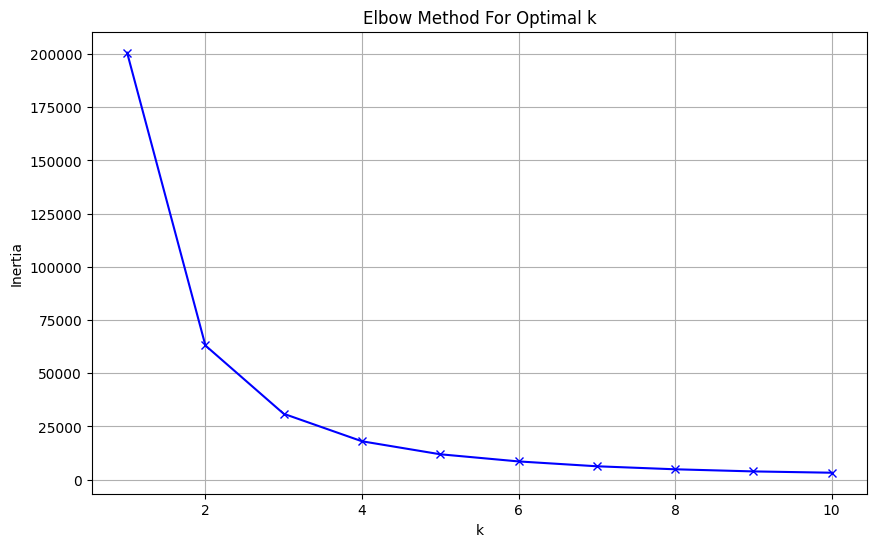

In [32]:
inertias = find_optimal_clusters(train, 'recency', max_clusters=10)

Looks like the optimal number of clusters is 4 for recency. Let's proceed with clustering.

In [33]:
# For training data
train_clusters, scaler, kmeans = cluster_the_feature_with_models_ordered(
    train, 
    column_name='recency', 
    n_clusters=4, 
    is_training=True
)
train['recency_cluster'] = train_clusters

# For test data - use the same scaler and kmeans model
test_clusters, _, _ = cluster_the_feature_with_models_ordered(
    test, 
    column_name='recency', 
    n_clusters=4,
    scaler=scaler,
    kmeans=kmeans,
    is_training=False
)
test['recency_cluster'] = test_clusters

In [34]:
train['recency_cluster'].value_counts()

recency_cluster
0.0    835172
1.0     67623
2.0     66658
3.0     45432
4.0     20868
Name: count, dtype: int64

In [35]:
test['recency_cluster'].value_counts()

recency_cluster
1.0    4939
2.0    3121
3.0    1350
4.0     419
0.0     171
Name: count, dtype: int64

In [36]:
train.groupby('recency_cluster')['recency'].describe()

,count,mean,std,min,25%,50%,75%,max
recency_cluster,,,,,,,,
0.0,835172.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1.0,67623.0,26.527099,11.591037,1.0,18.0,28.0,36.0,44.0
2.0,66658.0,63.170107,11.608101,45.0,53.0,62.0,73.0,85.0
3.0,45432.0,108.476470,15.093060,86.0,95.0,106.0,121.0,139.0
4.0,20868.0,171.338413,24.222632,140.0,151.0,166.0,188.0,244.0


In [37]:
train.shape

(1035753, 49)

### Frequency clustering

In [38]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Create subplot figure with 1 row and 2 columns
fig = make_subplots(rows=1, cols=2, subplot_titles=('Training Data Frequency', 'Test Data Frequency'))

# Add histogram for training data (now on left)
fig.add_trace(
    go.Histogram(x=train['frequency'], name='Training Data'),
    row=1, col=1
)

# Add histogram for test data (now on right)
fig.add_trace(
    go.Histogram(x=test['frequency'], name='Test Data'),
    row=1, col=2
)

# Update layout
fig.update_layout(
    title_text='Frequency Distribution (number of purchases)',
    showlegend=False,
    height=500
)

# Update x-axes labels
fig.update_xaxes(title_text='Number of Days', row=1, col=1)
fig.update_xaxes(title_text='Number of Days', row=1, col=2)

# Update y-axes labels
fig.update_yaxes(title_text='Count', row=1, col=1)
fig.update_yaxes(title_text='Count', row=1, col=2)

# Display the figure
fig.show()


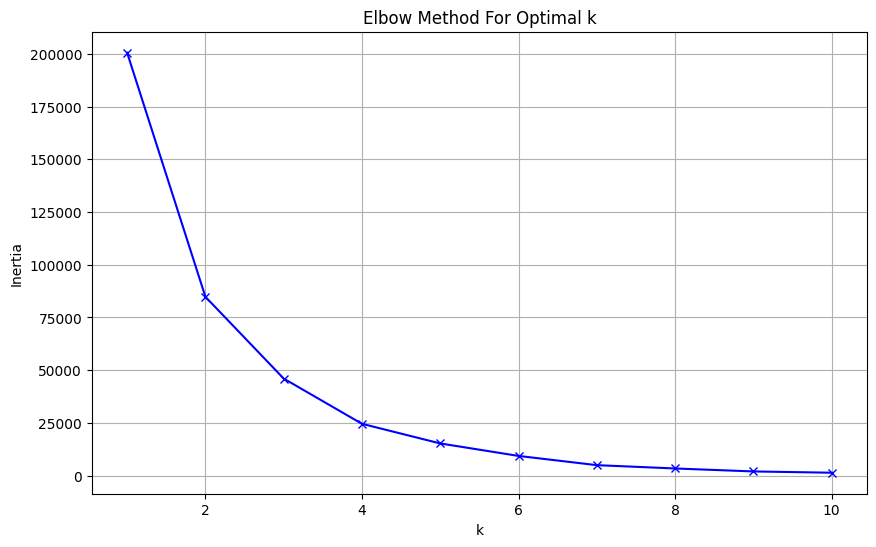

In [39]:
inertias = find_optimal_clusters(train, 'frequency', max_clusters=10)

Looks like the optimal number of clusters is 4 for frequency. Let's proceed with clustering.

In [40]:
# For training data
train_clusters, scaler, kmeans = cluster_the_feature_with_models_ordered(
    train, 
    column_name='frequency', 
    n_clusters=4, 
    is_training=True
)
train['frequency_cluster'] = train_clusters

# For test data - use the same scaler and kmeans model
test_clusters, _, _ = cluster_the_feature_with_models_ordered(
    test, 
    column_name='frequency', 
    n_clusters=4,
    scaler=scaler,
    kmeans=kmeans,
    is_training=False
)
test['frequency_cluster'] = test_clusters

In [41]:
train['frequency_cluster'].value_counts()

frequency_cluster
0.0    835172
1.0    128103
2.0     57124
3.0     14226
4.0      1128
Name: count, dtype: int64

In [42]:
test["frequency_cluster"].value_counts()

frequency_cluster
2.0    6767
3.0    3065
4.0     161
1.0       7
Name: count, dtype: int64

In [43]:
train.groupby('frequency_cluster')['frequency'].describe()

,count,mean,std,min,25%,50%,75%,max
frequency_cluster,,,,,,,,
0.0,835172.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1.0,128103.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
2.0,57124.0,2.285362,0.451590,2.0,2.0,2.0,3.0,3.0
3.0,14226.0,4.876353,1.126873,4.0,4.0,4.0,5.0,8.0
4.0,1128.0,12.039894,4.063952,9.0,9.0,10.0,13.0,29.0


### Monetary clustering

In [44]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Create subplot figure with 1 row and 2 columns
fig = make_subplots(rows=1, cols=2, subplot_titles=('Training Data monetary', 'Test Data Frequency'))

# Add histogram for training data (now on left)
fig.add_trace(
    go.Histogram(x=train['monetary'], name='Training Data'),
    row=1, col=1
)

# Add histogram for test data (now on right)
fig.add_trace(
    go.Histogram(x=test['monetary'], name='Test Data'),
    row=1, col=2
)

# Update layout
fig.update_layout(
    title_text='Monetary Distribution (number of purchases)',
    showlegend=False,
    height=500
)

# Update x-axes labels
fig.update_xaxes(title_text='Number of Days', row=1, col=1)
fig.update_xaxes(title_text='Number of Days', row=1, col=2)

# Update y-axes labels
fig.update_yaxes(title_text='Count', row=1, col=1)
fig.update_yaxes(title_text='Count', row=1, col=2)

# Display the figure
fig.show()

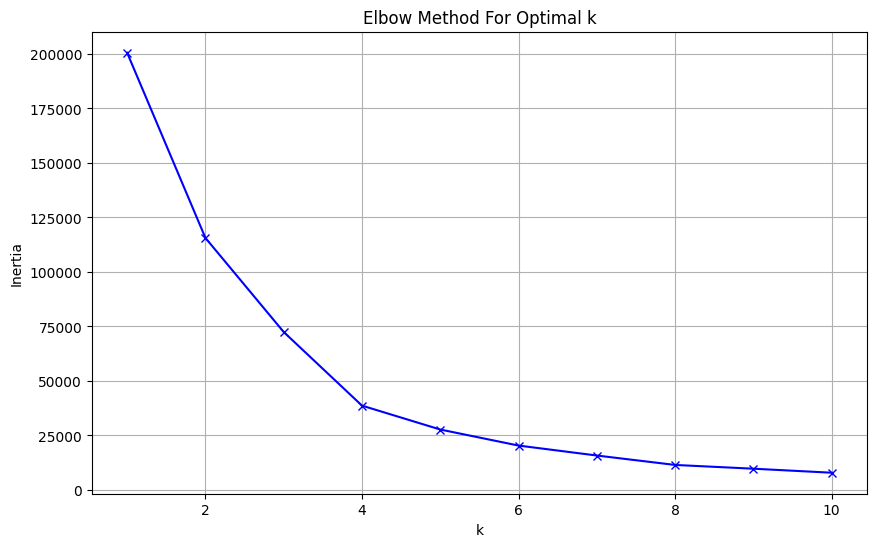

In [45]:
inertias = find_optimal_clusters(train, 'monetary', max_clusters=10)

Looks like the optimal number of clusters is 4 for monetary. Let's proceed with clustering.

In [46]:
# For training data
train_clusters, scaler, kmeans = cluster_the_feature_with_models_ordered(
    train, 
    column_name='monetary', 
    n_clusters=4, 
    is_training=True
)
train['monetary_cluster'] = train_clusters

# For test data - use the same scaler and kmeans model
test_clusters, _, _ = cluster_the_feature_with_models_ordered(
    test, 
    column_name='monetary', 
    n_clusters=4,
    scaler=scaler,
    kmeans=kmeans,
    is_training=False
)
test['monetary_cluster'] = test_clusters

In [47]:
train["monetary_cluster"].value_counts()

monetary_cluster
0.0    835172
1.0    177802
2.0     21368
3.0      1367
4.0        44
Name: count, dtype: int64

In [48]:
test["monetary_cluster"].value_counts()

monetary_cluster
1.0    6531
2.0    3224
3.0     243
4.0       2
Name: count, dtype: int64

In [49]:
train.groupby('monetary_cluster')['monetary'].describe()

,count,mean,std,min,25%,50%,75%,max
monetary_cluster,,,,,,,,
0.0,835172.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1.0,177802.0,1.893280,1.145198,1.0,1.0,1.0,2.0,5.0
2.0,21368.0,9.684154,4.193351,6.0,6.0,8.0,11.0,24.0
3.0,1367.0,38.324799,15.111634,25.0,28.0,33.0,44.0,120.0
4.0,44.0,204.909091,67.542517,125.0,150.0,180.0,250.0,430.0


### RFM Score Calculation

In [50]:
# For the RFM score calculation, we used the following formula:
train["rfm_score"] = (4 - train["recency_cluster"]) + train["frequency_cluster"] + train["monetary_cluster"]
test["rfm_score"] = (4 - test["recency_cluster"]) + test["frequency_cluster"] + test["monetary_cluster"]

In [51]:
train.to_csv('created_data/final_train_groups.csv', index=False)
test.to_csv('created_data/final_test_groups.csv', index=False)

## Model

In [52]:
train = pd.read_csv('created_data/final_train_groups.csv')
test = pd.read_csv('created_data/final_test_groups.csv')

In [53]:
train.columns

Index(['customer_id', 'product_id', 'purchase_date',
       'total_days_since_first_purchase', 'total_days_since_last_purchase',
       'purchase_span_days', 'purchase_frequency', 'avg_interval',
       'median_interval', 'interval_std', 'shortest_interval',
       'longest_interval', 'interval_skewness', 'interval_kurtosis',
       'last_quantity', 'total_quantity', 'recency', 'frequency', 'monetary',
       'total_products_by_customer', 'total_purchases_by_customer',
       'avg_purchase_frequency_by_customer', 'customer_product_ratio',
       'product_total_customers', 'product_total_purchases',
       'purchase_count_last_7d', 'quantity_total_last_7d',
       'purchase_frequency_last_7d', 'purchase_count_last_14d',
       'quantity_total_last_14d', 'purchase_frequency_last_14d',
       'purchase_count_last_30d', 'quantity_total_last_30d',
       'purchase_frequency_last_30d', 'purchase_count_last_90d',
       'quantity_total_last_90d', 'purchase_frequency_last_90d', 'day_of_week',


In [54]:
train['purchase_date'] = pd.to_datetime(train['purchase_date'])
test['purchase_date'] = pd.to_datetime(test['purchase_date'])

In [55]:
train.drop(columns=['purchase_date'],inplace=True)
test.drop(columns=['purchase_date'],inplace=True)

train['customer_id']=train['customer_id'].astype(int)
train['product_id']=train['product_id'].astype(int)
test['customer_id']=test['customer_id'].astype(int)
test['product_id']=test['product_id'].astype(int)

In [56]:
train["label"].value_counts()

label
0.0    1000786
4.0      12644
3.0       9990
2.0       7105
1.0       5228
Name: count, dtype: int64

In [57]:
train["customer_id"].nunique()

46138

In [58]:
product_catalog_df = pd.read_csv('data/product_catalog.csv')

train = train.merge(product_catalog_df.iloc[:,:-1],on='product_id',how='left')
test = test.merge(product_catalog_df.iloc[:,:-1],on='product_id',how='left')

In [59]:
train = train.sort_values(by=['year','month','day_of_month']).reset_index(drop=True)

In [60]:
train = train[train['label'] != 0].reset_index(drop=True)

In [61]:
train["label"].value_counts()

label
4.0    12644
3.0     9990
2.0     7105
1.0     5228
Name: count, dtype: int64

In [62]:
len(train.columns)

57

In [63]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 57 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   customer_id                         10000 non-null  int64  
 1   product_id                          10000 non-null  int64  
 2   total_days_since_first_purchase     10000 non-null  int64  
 3   total_days_since_last_purchase      10000 non-null  int64  
 4   purchase_span_days                  10000 non-null  int64  
 5   purchase_frequency                  10000 non-null  float64
 6   avg_interval                        10000 non-null  float64
 7   median_interval                     10000 non-null  float64
 8   interval_std                        6837 non-null   float64
 9   shortest_interval                   10000 non-null  float64
 10  longest_interval                    10000 non-null  float64
 11  interval_skewness                   9963 n

In [64]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34967 entries, 0 to 34966
Data columns (total 57 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   customer_id                         34967 non-null  int64  
 1   product_id                          34967 non-null  int64  
 2   total_days_since_first_purchase     34967 non-null  int64  
 3   total_days_since_last_purchase      34967 non-null  int64  
 4   purchase_span_days                  34967 non-null  int64  
 5   purchase_frequency                  34967 non-null  float64
 6   avg_interval                        34967 non-null  float64
 7   median_interval                     34967 non-null  float64
 8   interval_std                        30997 non-null  float64
 9   shortest_interval                   34967 non-null  float64
 10  longest_interval                    34967 non-null  float64
 11  interval_skewness                   34931

## Grid Search

In [66]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer
import numpy as np

def score(y_true, y_pred):
    points = 0
    for true, pred in zip(y_true, y_pred):
        points += 1
        if true == pred:
            points += 3
        
    return points


xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    eval_metric=['mlogloss', 'merror'],
    enable_categorical=True
)

tscv = TimeSeriesSplit(n_splits=7)
scorer = make_scorer(score)

param_grid = {
    'max_depth': [4, 5, 6],
    'learning_rate': [0.05, 0.07],
    'subsample': [0.8, 0.85, 0.9],
    'colsample_bytree': [0.8, 0.82, 0.85],
    'min_child_weight': [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring=scorer,
    cv=tscv,
    n_jobs=-2,  # Use all CPU cores
    verbose=1,
    return_train_score=True
)

X = train.drop(columns=['label'])
y = train['label'] - 1  # Adjust labels to start from 0

# Fit grid search
print("Starting grid search...")
grid_search.fit(X, y)

# Print results
print("\nBest parameters found:")
print(grid_search.best_params_)
print("\nBest cross-validation score:", grid_search.best_score_)

Starting grid search...
Fitting 7 folds for each of 162 candidates, totalling 1134 fits

Best parameters found:
{'colsample_bytree': 0.85, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.9}

Best cross-validation score: 9263.42857142857


## XGBOOST Model


Fold 1
3    2852
2    1242
1     188
0      88
Name: count, dtype: int64
Fold 1 Macro F1 Score: 0.2439
Fold 1 Custom Score: 9065
Fold 1 Custom Score per Sample: 2.0744

Fold 2
3    3865
2     288
1     160
0      57
Name: count, dtype: int64
Fold 2 Macro F1 Score: 0.2323
Fold 2 Custom Score: 9584
Fold 2 Custom Score per Sample: 2.1931

Fold 3
3    3541
2     575
1     221
0      33
Name: count, dtype: int64
Fold 3 Macro F1 Score: 0.2446
Fold 3 Custom Score: 9476
Fold 3 Custom Score per Sample: 2.1684

Fold 4
3    3816
2     368
1     153
0      33
Name: count, dtype: int64
Fold 4 Macro F1 Score: 0.2305
Fold 4 Custom Score: 9668
Fold 4 Custom Score per Sample: 2.2124

Fold 5
3    3783
2     466
1      88
0      33
Name: count, dtype: int64
Fold 5 Macro F1 Score: 0.2209
Fold 5 Custom Score: 9560
Fold 5 Custom Score per Sample: 2.1876

Fold 6
3    3879
2     274
1     152
0      65
Name: count, dtype: int64
Fold 6 Macro F1 Score: 0.2188
Fold 6 Custom Score: 9518
Fold 6 Custom Score per S

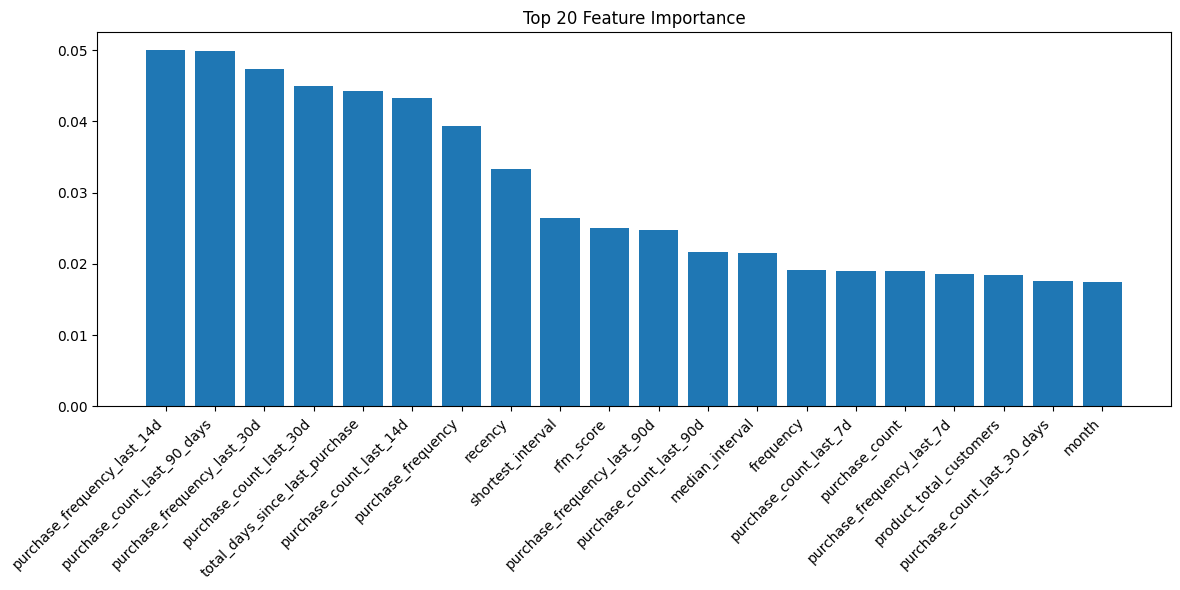

In [67]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt


# Convert categorical columns to numeric
categorical_features = ['customer_id', 'product_id', 
                       'manufacturer_id', 'attribute_1',
                       'attribute_2', 'attribute_3', 'attribute_4', 'attribute_5']

# Prepare train data
X = train.drop(columns=['label'])
y = train['label'] - 1  # Shift labels down by 1 to start from 0

# Encode categorical features
for col in categorical_features:
    X[col] = X[col].astype('category').cat.codes
    test[col] = test[col].astype('category').cat.codes

# Cross validation setup
n_splits = 7
tscv = TimeSeriesSplit(n_splits=n_splits)

# Array for test predictions
test_predictions_probability = np.zeros((len(test), 4))

# Model parameters
model_params = {
    'objective': 'multi:softmax',
    'num_class': 4,
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.82,
    'min_child_weight': 4,
    'random_state': 42,
    'eval_metric': ['mlogloss', 'merror'],
    "enable_categorical": True
}

# Lists to store cross validation scores
fold_f1_scores = []
fold_custom_scores = []

# Cross validation
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    print(f"\nFold {fold}")
    
    # Split train and validation sets
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    
    model = xgb.XGBClassifier(**model_params)

    model.fit(X_train, y_train)

    # Make predictions
    val_preds = model.predict(X_val)
    print(pd.Series(val_preds).value_counts())
    
    # Calculate metrics
    fold_f1 = f1_score(y_val, val_preds, average='macro')
    fold_f1_scores.append(fold_f1)
    
    # Add 1 back to predictions and true values for custom score calculation
    custom_score = score(y_val, val_preds)
    fold_custom_scores.append(custom_score)
    
    print(f"Fold {fold} Macro F1 Score: {fold_f1:.4f}")
    print(f"Fold {fold} Custom Score: {custom_score}")
    print(f"Fold {fold} Custom Score per Sample: {custom_score/len(y_val):.4f}")
    
    # Accumulate val predictions
    test_predictions_probability += model.predict(test[X.columns], output_margin=True)

# Print average scores
mean_f1 = np.mean(fold_f1_scores)
std_f1 = np.std(fold_f1_scores)
print(f"\nMean Macro F1 Score: {mean_f1:.4f} (±{std_f1:.4f})")

mean_custom = np.mean(fold_custom_scores)
std_custom = np.std(fold_custom_scores)
print(f"\nMean Custom Score: {mean_custom:.2f} (±{std_custom:.2f})")
print(f"Mean Custom Score per Sample: {mean_custom/len(y_val):.4f} (±{std_custom/len(y_val):.4f})")


importance_dict = {}
for idx, importance in enumerate(model.feature_importances_):
    importance_dict[X.columns[idx]] = importance

# Create DataFrame of feature importances
importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance': list(importance_dict.values())
}).sort_values('Importance', ascending=False)

# Print top 50 features
print("\nFeature Importance:")
print(importance_df.head(50))

# Plot top 20 features
plt.figure(figsize=(12, 6))
top_features = importance_df.head(20)
plt.bar(top_features['Feature'], top_features['Importance'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()

# Average test predictions
test_predictions_probability /= n_splits

# Get final predictions 
test_set_predictions = np.argmax(test_predictions_probability, axis=1)
test_set_predictions += 1  # Shift predictions back up by 1

In [68]:
# Create submission DataFrame
final_results = pd.DataFrame({
    'id': test.id,
    'customer_id': test['customer_id'],
    'product_id': test['product_id'],
    'prediction': test_set_predictions
})
final_results.to_csv('xgboostfinal.csv',index=False)
final_results['prediction'].value_counts()

prediction
4    8994
3     797
1     178
2      31
Name: count, dtype: int64